# DBSCAN Clustering Notebook
## Table of Contents
1. [Introduction & Definition](#1-introduction--definition)
2. [How It Works — Math & Intuition](#2-how-it-works--math--intuition)
3. [When To Use DBSCAN](#3-when-to-use-dbscan)
4. [Pros & Cons](#4-pros--cons)
5. [Mall Customer Segmentation Dataset](#mall-customer-segmentation-dataset)
6. [Exploratory Data Analysis (EDA)](#exploratory-data-analysis)
   - 6.1 Import Libraries
   - 6.2 Load Dataset
   - 6.3 Dataset Overview
   - 6.4 Missing Values & Duplicates
   - 6.5 Summary Statistics
   - 6.6 Feature Distributions
   - 6.7 Feature Relationships (Income vs. Spending, Age vs. Spending)
   - 6.8 Correlation Heatmap
7. [Data Cleaning & Preprocessing](#7-data-cleaning--preprocessing)
8. [Choosing DBSCAN Hyperparameters — eps & min_samples](#8-choosing-dbscan-hyperparameters)
9. [Model Training — Fitting DBSCAN](#9-model-training)
10. [Cluster Evaluation — DBSCAN vs. KMeans](#10-cluster-evaluation)
11. [Visualizing & Interpreting the Clusters](#11-visualizing--interpreting-the-clusters)
12. [Conclusion](#12-conclusion)

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Introduction & Definition

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) is a **machine learning
algorithm used for clustering**, an *unsupervised* task where the goal is to group similar data points
together **without** using any target label.

Unlike **K-Means**, which forces every point into one of *k* round, roughly equal-sized clusters,
DBSCAN groups points that are **densely packed together** and automatically marks points that sit in
low-density regions as **noise / outliers**. It never needs to be told how many clusters to look for —
the number of clusters emerges naturally from the density of the data.

## 2. How It Works — Math & Intuition

DBSCAN uses two main parameters:

- **`eps` (ε):** how close two points need to be to be considered neighbors.
- **`min_samples`:** the minimum number of points needed in an ε-neighborhood to consider an area dense.

For each point `p`, DBSCAN looks at all points within the `eps` radius:

$$
N_\varepsilon(p) = \{q : \text{dist}(p,q) \le \varepsilon\}
$$

Based on the number of nearby points, each point can be:

- **Core point:** has at least `min_samples` points nearby. It is in a dense area and can create or expand a cluster.
- **Border point:** does not have enough neighbors to be a core point, but it is close to a core point. It belongs to that cluster.
- **Noise point:** is not close enough to any core point and does not have enough neighbors itself. DBSCAN labels it `-1`.

DBSCAN builds clusters by connecting nearby **core points**. If one core point is close to another core point, they become part of the same cluster. Border points are then added to the nearest connected cluster.

This is why DBSCAN is good at finding **clusters of different and irregular shapes**, such as circles, spirals, or crescents.

Unlike **K-Means**, DBSCAN does not try to create clusters around fixed centroids. It simply looks for **dense groups of nearby points**, which allows it to discover much more flexible cluster shapes.

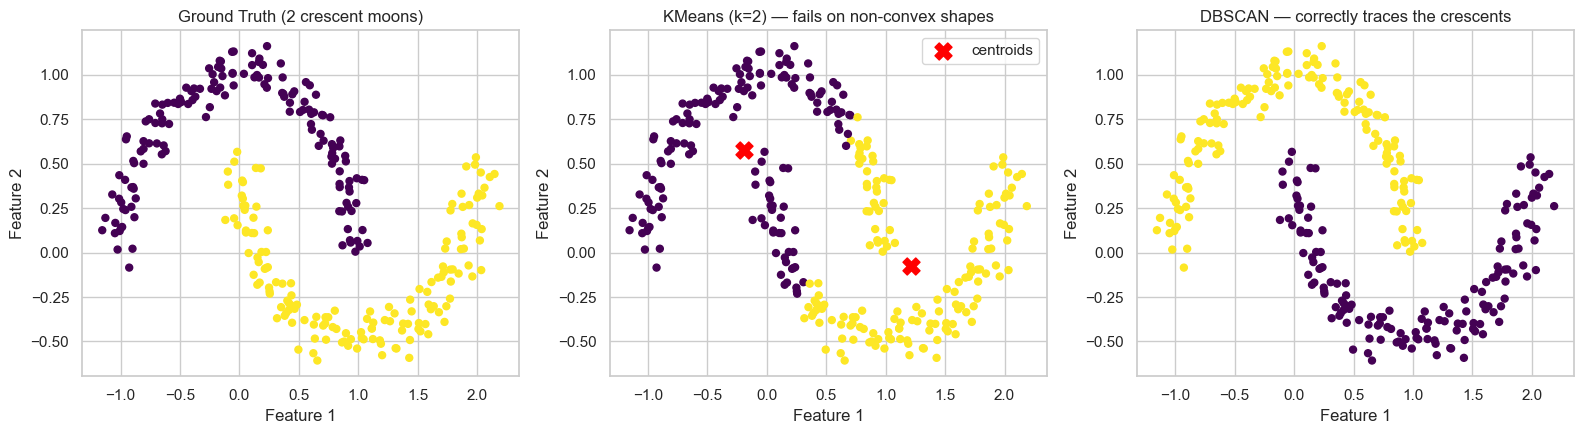

In [2]:
# Demonstrate WHY density-based clustering matters: generate two interleaving crescent
# ("two moons") shapes that are NOT linearly separable by centroids.
X_demo, y_demo_true = make_moons(n_samples=300, noise=0.07, random_state=RANDOM_STATE)

# Fit KMeans (k=2) - a centroid-based algorithm that assumes round, convex clusters
kmeans_demo = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
kmeans_labels_demo = kmeans_demo.fit_predict(X_demo)

# Fit DBSCAN - a density-based algorithm that makes no assumption about cluster shape
dbscan_demo = DBSCAN(eps=0.2, min_samples=5)
dbscan_labels_demo = dbscan_demo.fit_predict(X_demo)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(X_demo[:, 0], X_demo[:, 1], c=y_demo_true, cmap="viridis", s=25)
axes[0].set_title("Ground Truth (2 crescent moons)")

axes[1].scatter(X_demo[:, 0], X_demo[:, 1], c=kmeans_labels_demo, cmap="viridis", s=25)
axes[1].scatter(kmeans_demo.cluster_centers_[:, 0], kmeans_demo.cluster_centers_[:, 1],
                 c="red", marker="X", s=150, label="centroids")
axes[1].set_title("KMeans (k=2) — fails on non-convex shapes")
axes[1].legend()

axes[2].scatter(X_demo[:, 0], X_demo[:, 1], c=dbscan_labels_demo, cmap="viridis", s=25)
axes[2].set_title("DBSCAN — correctly traces the crescents")

for ax in axes:
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

### What This Plot Shows

This example shows why DBSCAN can be better than KMeans when clusters have unusual shapes.

We create a dataset with **two interleaving crescent-shaped groups** (the "two moons").

- **Ground Truth:** Shows the two actual crescent-shaped clusters.
- **KMeans:** Tries to divide the data based on distance to two **centroids**. Because KMeans works best with round or simple-shaped clusters, it cannot follow the curved shape of the moons and separates the points incorrectly.
- **DBSCAN:** Looks for **dense groups of nearby points** instead of using centroids. It follows the curves naturally and correctly identifies the two moons.

### Main Idea

The important difference is:

**KMeans → "Which centroid is this point closest to?"**

**DBSCAN → "Which dense group does this point belong to?"**

This allows DBSCAN to find clusters with **irregular shapes**, such as crescents, spirals, or rings.

Another important advantage is that DBSCAN does **not need to know the number of clusters beforehand**. KMeans needs `k=2`, while DBSCAN discovers the number of clusters from the density of the data.

## 3. When To Use DBSCAN

DBSCAN is a strong choice when:

- Clusters are **non-convex / arbitrarily shaped** (crescents, rings, elongated blobs) — situations
  where centroid-based methods like K-Means systematically fail.
- The dataset contains **outliers or noise** that should be explicitly identified rather than forced
  into the nearest cluster (fraud detection, sensor-error detection, rare-event spotting).
- The **number of clusters is unknown in advance** — DBSCAN infers it from density instead of requiring
  a pre-set *k*.
- Clusters may have **similar density** to each other but very different sizes/shapes — spatial data
  (geolocation clustering, hotspot detection), image segmentation, and network-traffic anomaly
  detection are classic use cases.

It is a poorer fit when clusters have **very different densities** (a single global `eps` can't serve
both a tight and a sparse cluster well) or when the data is **very high-dimensional**, where distance
metrics become less meaningful (the "curse of dimensionality").

## 4. Pros & Cons

**Pros**
- Does **not require specifying the number of clusters** upfront.
- Can find **arbitrarily-shaped clusters**, not just round/convex ones.
- Has a built-in, principled notion of **outliers/noise** (label `-1`) instead of forcing every point
  into a cluster.
- Robust to a moderate amount of noise in the data.

**Cons**
- Sensitive to the choice of **`eps`** and **`min_samples`** — a poor choice can merge distinct
  clusters or shatter one cluster into many.
- Struggles when clusters have **widely varying densities**, since a single global `eps` is used.
- Distance-based, so it degrades in **high-dimensional feature spaces** without dimensionality
  reduction or careful scaling.
- Not guaranteed to produce the same result if points are processed in a different order in rare
  border-point edge cases.

# Mall Customer Segmentation Dataset

We now move from theory to practice using the **Mall Customer Segmentation** dataset (200 customers
of a shopping mall, with membership-card-derived `Annual Income` and a mall-assigned `Spending Score`).
This is a classic, widely-used benchmark for **customer segmentation** — precisely the kind of task
where DBSCAN's ability to find naturally-shaped groups *and* flag atypical customers as outliers is
valuable to a marketing team.

## Exploratory Data Analysis

### 6.1 Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

### 6.2 Load Dataset

In [4]:
# The dataset is a single CSV with columns: CustomerID, Gender, Age, Annual Income (k$), Spending Score (1-100)
DATA_URL = "https://raw.githubusercontent.com/gakudo-ai/open-datasets/refs/heads/main/Mall_Customers.csv"
df = pd.read_csv(DATA_URL)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 6.3 Dataset Overview

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


**What to look for:** The dataset holds 200 rows and 5 columns. `Gender` is categorical, while
`Age`, `Annual Income (k$)`, and `Spending Score (1-100)` are numeric. `CustomerID` is just a row
identifier and carries no clustering signal, so it will be dropped during cleaning.

### 6.4 Missing Values & Duplicates

In [6]:
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0


**What this tells us:** There are no missing values and no duplicate rows. This is a clean,
ready-to-use dataset, so the cleaning step later mainly consists of dropping the identifier column and
scaling — no imputation or de-duplication is required.

### 6.5 Summary Statistics

In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


**What to look for:** `Age` ranges from 18 to 70 (mean ~38.9). `Annual Income (k$)` ranges from
15k to 137k (mean ~60.6k). `Spending Score` is a bounded 1–100 index the mall assigns based on
purchasing behavior (mean ~50.2). The very different scales across these three columns is exactly why
we must standardize the features before computing Euclidean distances for DBSCAN — otherwise income
(with a spread in the tens of thousands) would completely dominate the distance calculation.

### 6.6 Feature Distributions

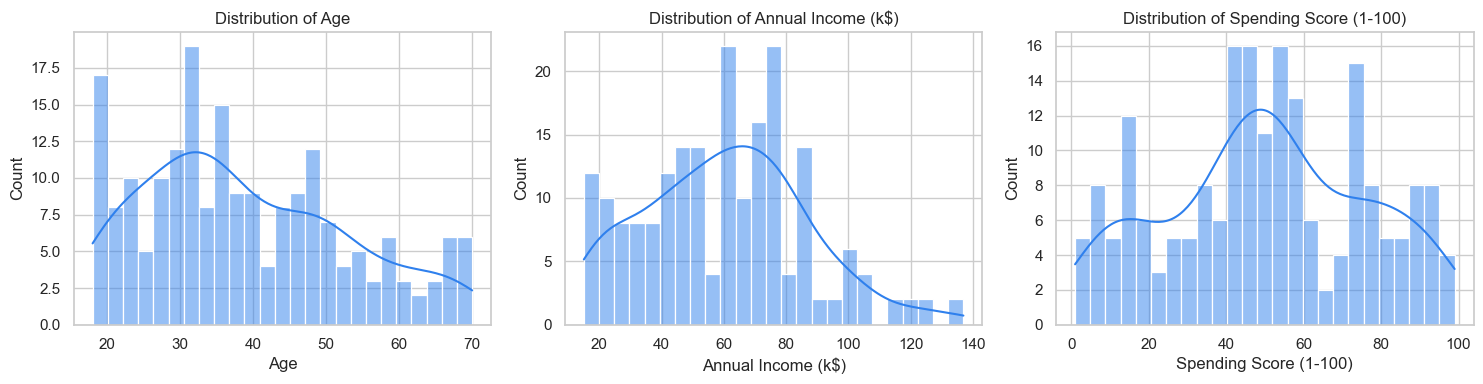

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["Age", "Annual Income (k$)", "Spending Score (1-100)"]):
    sns.histplot(df[col], bins=25, kde=True, ax=ax, color="#2f80ed")
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

### What These Distributions Show

These histograms show how the three main features are distributed across the customers:

- **Age:** Most customers are relatively young, mainly in their 20s and 30s. The number of customers decreases as age increases.
- **Annual Income:** Most customers have a moderate income, while a smaller number have much higher incomes.
- **Spending Score:** Customers are spread across almost the entire 1–100 range, from low spenders to high spenders.

### Why This Matters for Clustering

The features show enough variation between customers to make clustering useful.

For example, we may find groups such as:

- Young customers with high spending
- High-income customers with low spending
- Customers with average income and spending
- Low-income customers with high spending

DBSCAN can use these differences to find **natural groups of customers based on their characteristics and behavior**.

### 6.7 Feature Relationships (Income vs. Spending, Age vs. Spending)

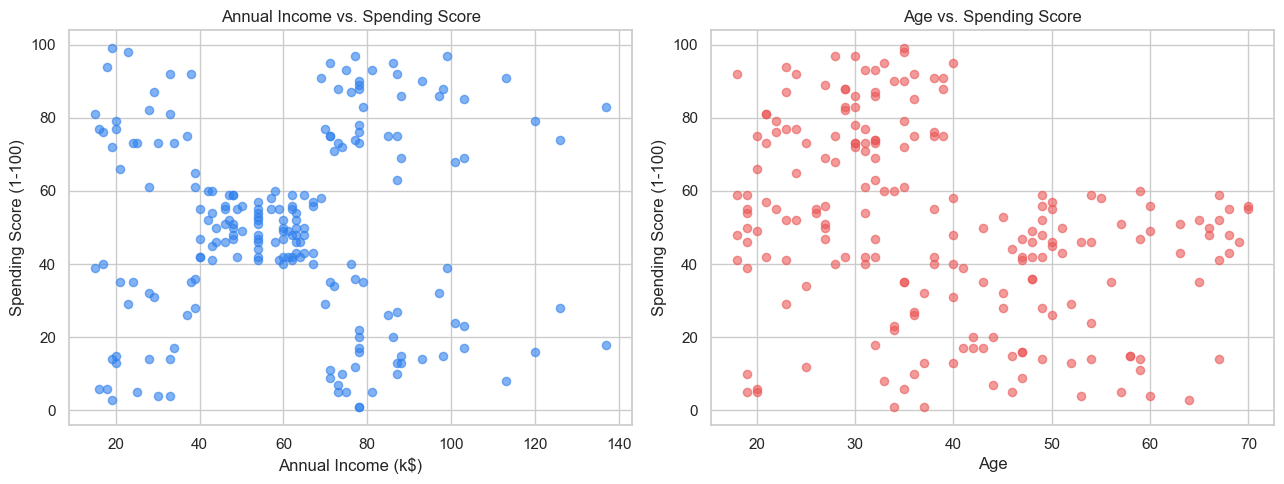

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], alpha=0.6, s=35, color="#2f80ed")
axes[0].set_xlabel("Annual Income (k$)")
axes[0].set_ylabel("Spending Score (1-100)")
axes[0].set_title("Annual Income vs. Spending Score")

axes[1].scatter(df["Age"], df["Spending Score (1-100)"], alpha=0.6, s=35, color="#eb5757")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Spending Score (1-100)")
axes[1].set_title("Age vs. Spending Score")

plt.tight_layout()
plt.show()

### What These Scatter Plots Show

These two plots help us see whether the features form visible groups.

- **Annual Income vs. Spending Score:** This plot shows several groups of customers with different combinations of income and spending. For example, we can see customers with low income and low spending, low income and high spending, high income and low spending, and high income and high spending. The groups are much easier to see here.

- **Age vs. Spending Score:** The points are more spread out and there are no clear groups. Customers of different ages can have both low and high spending scores.

### Why This Matters for Clustering

The **Income vs. Spending Score** plot shows the clearest clustering structure.

This suggests that these two features will be more useful for DBSCAN because DBSCAN works best when groups of points form **dense and separated regions**.

So, for our clustering analysis, **Annual Income and Spending Score are likely to provide the strongest clustering signal**.

### 6.8 Correlation Heatmap

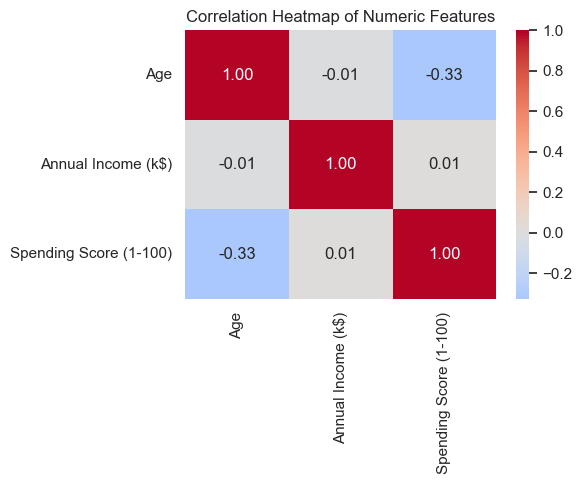

In [10]:
plt.figure(figsize=(6, 5))
numeric_df = df.drop(columns=["CustomerID"]).select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

### What This Correlation Heatmap Shows

The heatmap shows how strongly the numeric features are related to each other.

- **Age, Annual Income, and Spending Score** all have weak correlations.
- This means that knowing one feature does not tell us much about another.
- For example, having a higher income does not necessarily mean having a higher Spending Score.

### Why This Matters for Clustering

The weak correlations do **not** mean that there are no useful customer groups.

Instead, the scatter plots showed that the interesting patterns come from the **shape and density of the points**, rather than from simple straight-line relationships.

This is important for DBSCAN because DBSCAN does not look for linear relationships. It looks for **dense groups of nearby points**, which makes it suitable for discovering these customer segments.

## 7. Data Cleaning & Preprocessing

In [ ]:
# Drop the identifier column - it carries no clustering signal
df_model = df.drop(columns=["CustomerID"]).copy()

# Encode Gender numerically in case we want to inspect cluster composition by gender later,
# though it is not used as a clustering feature here (Income & Spending Score are the focus)
df_model["Gender"] = df_model["Gender"].map({"Male": 0, "Female": 1})

# Select the two features with the clearest cluster structure from the EDA: Income & Spending Score
feature_cols = ["Annual Income (k$)", "Spending Score (1-100)"]
X_raw = df_model[feature_cols].values

# Standardize features (zero mean, unit variance) - essential before computing Euclidean
# distances for DBSCAN, so that Income (scale ~15-137) does not dominate Spending Score (scale 1-100)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("Scaled feature means:", X_scaled.mean(axis=0).round(3))
print("Scaled feature stds: ", X_scaled.std(axis=0).round(3))

Scaled feature means: [-0. -0.]
Scaled feature stds:  [1. 1.]


### Preparing the Data for DBSCAN

Before applying DBSCAN, we need to prepare the data correctly.

1. **Remove `CustomerID`**
   - It is only an identifier and does not describe customer behavior.
   - Including it could negatively affect the clustering.

2. **Encode `Gender`**
   - `Male` is converted to `0` and `Female` to `1`.
   - We keep it in the dataset so we can analyze the gender composition of the clusters later.
   - However, **Gender is not used for clustering**.

3. **Select the clustering features**
   - We use only:
     - `Annual Income (k$)`
     - `Spending Score (1-100)`
   - Our earlier analysis showed that these two features have the clearest cluster structure.

4. **Standardize the features**
   - DBSCAN uses distances to find nearby points.
   - Income and Spending Score have different ranges, so we scale them to the same level.
   - After scaling, both features have:
     - Mean ≈ `0`
     - Standard deviation ≈ `1`

### Why These Two Features?

We deliberately use **Annual Income and Spending Score** because they showed the clearest groups in our visual analysis.

We do not include `Age` at this stage because its distribution did not show clear density-based groups. Adding it could make the distance calculation less focused and potentially make the clusters harder for DBSCAN to detect.

## 8. Choosing DBSCAN Hyperparameters — eps & min_samples

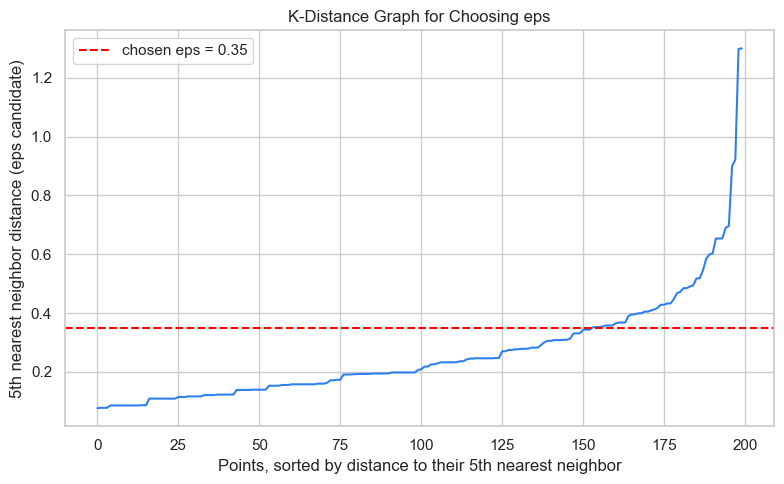

In [12]:
# Rule of thumb for min_samples: at least (2 x number of dimensions). We have 2 features, so
# we start at min_samples = 4-5, which is also the commonly recommended default for 2D data.
min_samples = 5

# To choose eps, use the k-distance graph: for each point, compute the distance to its
# k-th nearest neighbor (k = min_samples), sort these distances, and look for the "elbow" -
# the point of sharpest increase, which marks the natural density threshold in the data.
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort the distance to the k-th nearest neighbor for every point, ascending
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances, color="#2f80ed")
plt.xlabel("Points, sorted by distance to their 5th nearest neighbor")
plt.ylabel("5th nearest neighbor distance (eps candidate)")
plt.title("K-Distance Graph for Choosing eps")
plt.axhline(y=0.35, color="red", linestyle="--", label="chosen eps = 0.35")
plt.legend()
plt.tight_layout()
plt.show()

### How We Choose `eps`

The **k-distance graph** helps us choose a good value for `eps`.

- On the left, most points have a small distance to their 5th nearest neighbor. This means they are in **dense areas**.
- As we move to the right, the distance starts increasing quickly. These points are in **sparser areas** and may be near the edge of a cluster or be outliers.
- The point where the curve starts to rise sharply is called the **elbow**.

The elbow gives us a good estimate for `eps` because it separates **dense regions from sparse regions**.

In this graph, the elbow is around **0.35**, so we choose:

**`eps = 0.35`**

Because the features were standardized, this value is measured in **standardized units**, not the original income or spending-score units.

## 9. Model Training

In [13]:
# Fit DBSCAN with the hyperparameters chosen from the k-distance graph
dbscan = DBSCAN(eps=0.35, min_samples=5)
cluster_labels = dbscan.fit_predict(X_scaled)

df_model["Cluster"] = cluster_labels

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = np.sum(cluster_labels == -1)

print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points (outliers): {n_noise} out of {len(cluster_labels)} "
      f"({n_noise / len(cluster_labels):.1%})")
print("\nPoints per cluster (label -1 = noise):")
print(pd.Series(cluster_labels).value_counts().sort_index())

Number of clusters found: 6
Number of noise points (outliers): 23 out of 200 (11.5%)

Points per cluster (label -1 = noise):
-1    23
 0    16
 1    12
 2     7
 3    88
 4    31
 5    23
Name: count, dtype: int64


### DBSCAN Results

After applying DBSCAN with `eps = 0.35` and `min_samples = 5`, the algorithm found:

- **6 clusters**
- **23 noise points (outliers)** out of 200 customers
- This means **11.5% of the customers** were identified as noise.

The important point is that we **did not tell DBSCAN to find 6 clusters**. Unlike KMeans, DBSCAN automatically discovered the number of clusters by looking at the density of the data.

The **23 noise points** are customers that do not belong clearly to any dense group. Instead of forcing them into a cluster, DBSCAN labels them as **`-1`**, allowing us to investigate them separately.

So, DBSCAN has identified **six customer segments + a group of potential outliers** based only on income and spending behavior.

## 10. Cluster Evaluation

In [14]:
# Silhouette Score: measures how similar a point is to its own cluster vs. the nearest other
# cluster (range -1 to 1; higher is better-separated). Noise points are excluded from this metric
# since they do not belong to any cluster by definition.
mask = cluster_labels != -1
dbscan_silhouette = silhouette_score(X_scaled[mask], cluster_labels[mask])

# Compare against KMeans forced to find the same number of clusters, to check whether a simple
# centroid-based method would have found an equally good (or better) partition of this data
kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

print(f"DBSCAN silhouette score (noise excluded): {dbscan_silhouette:.3f}")
print(f"KMeans (k={n_clusters}) silhouette score:      {kmeans_silhouette:.3f}")

DBSCAN silhouette score (noise excluded): 0.558
KMeans (k=6) silhouette score:      0.540


### Evaluating the Clusters with Silhouette Score

The **Silhouette Score** tells us how well each point fits into its cluster.

It ranges from **-1 to 1**:

- **Close to 1:** the point is well inside its cluster and far from other clusters.
- **Around 0:** the point is close to the boundary between clusters.
- **Below 0:** the point may be assigned to the wrong cluster.

A **higher score generally means better-separated clusters**.

In our results:

- **DBSCAN:** `0.558`
- **KMeans:** `0.540`

Both scores are reasonably good, but DBSCAN has a slightly higher score, meaning its clusters are a little better separated according to this metric.

However, the main advantage of DBSCAN is not just the score. **DBSCAN also identified 23 noise points**, while KMeans must assign every customer to a cluster.

So, DBSCAN gives us both **customer clusters and potential outliers**, which is useful when we want to identify unusual customer behavior.

## 11. Visualizing & Interpreting the Clusters

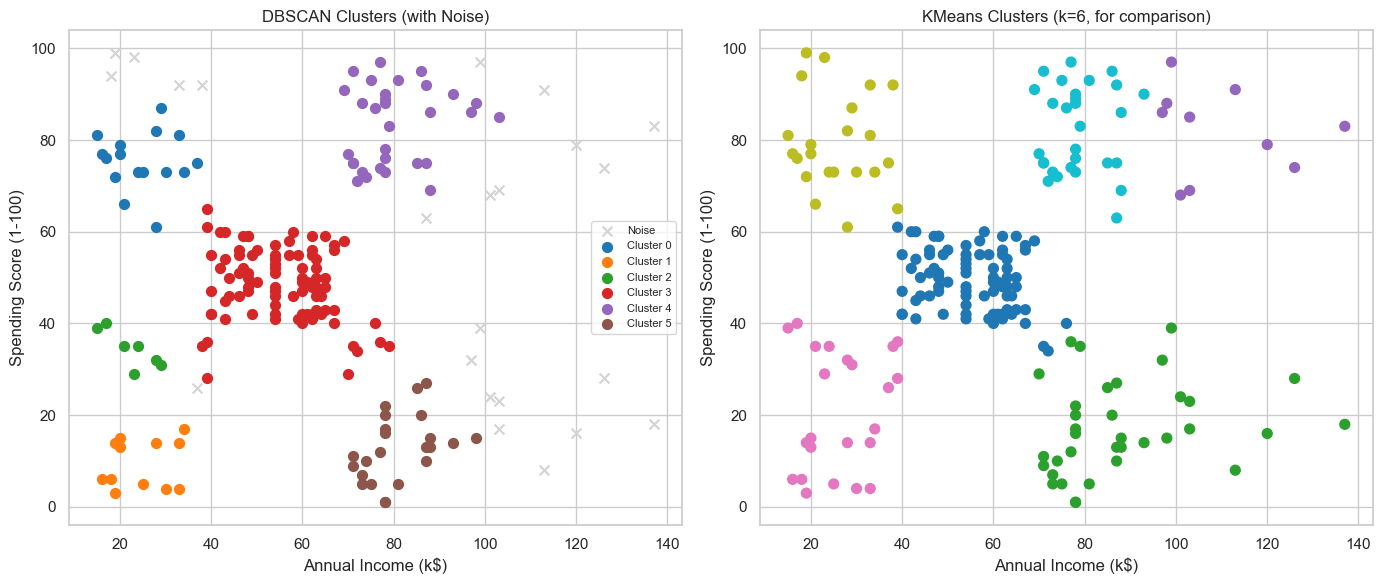

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- DBSCAN plot ---
palette = sns.color_palette("tab10", n_clusters)
for label in sorted(set(cluster_labels)):
    subset = df_model[df_model["Cluster"] == label]
    if label == -1:
        axes[0].scatter(subset["Annual Income (k$)"], subset["Spending Score (1-100)"],
                         c="lightgray", marker="x", s=50, label="Noise")
    else:
        axes[0].scatter(subset["Annual Income (k$)"], subset["Spending Score (1-100)"],
                         color=palette[label], s=50, label=f"Cluster {label}")
axes[0].set_xlabel("Annual Income (k$)")
axes[0].set_ylabel("Spending Score (1-100)")
axes[0].set_title("DBSCAN Clusters (with Noise)")
axes[0].legend(fontsize=8)

# --- KMeans plot, for direct visual comparison ---
scatter = axes[1].scatter(df_model["Annual Income (k$)"], df_model["Spending Score (1-100)"],
                           c=kmeans_labels, cmap="tab10", s=50)
axes[1].set_xlabel("Annual Income (k$)")
axes[1].set_ylabel("Spending Score (1-100)")
axes[1].set_title(f"KMeans Clusters (k={n_clusters}, for comparison)")

plt.tight_layout()
plt.show()

### DBSCAN vs. KMeans

The plots show the clusters found by DBSCAN and KMeans using the same two features.

- **DBSCAN (left):** Finds the customer groups and also marks some unusual points as **noise** using gray `x` markers.
- **KMeans (right):** Also finds similar groups, but it must assign **every customer** to a cluster.

In this dataset, both methods produce fairly similar clusters because the groups are relatively well separated.

However, the important difference is that **DBSCAN can identify customers that do not clearly belong to any group**, while KMeans always forces every customer into one of its clusters.

This makes DBSCAN especially useful when **detecting unusual or potentially abnormal customer behavior** is important.

In [16]:
# Business-friendly summary of each DBSCAN segment
cluster_summary = (
    df_model[df_model["Cluster"] != -1]
    .groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]
    .mean()
    .round(1)
)
cluster_summary["Count"] = df_model[df_model["Cluster"] != -1].groupby("Cluster").size()
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,24.8,24.8,75.4,16
1,48.8,24.6,9.6,12
2,36.7,22.4,34.4,7
3,42.9,55.2,48.6,88
4,32.8,80.3,83.2,31
5,41.2,81.0,12.8,23


### Interpreting the Customer Segments

The table shows the **average age, income, spending score, and number of customers** in each DBSCAN cluster.

This helps us turn the technical clusters into understandable customer groups:

- **Cluster 0:** Young customers with low income but high spending → **Young high spenders**
- **Cluster 1:** Older customers with low income and very low spending → **Low-income low spenders**
- **Cluster 2:** Customers with low income and moderate spending → **Moderate spenders**
- **Cluster 3:** The largest group, with average income and spending → **Average customers**
- **Cluster 4:** Higher-income customers with very high spending → **High-value customers**
- **Cluster 5:** Higher-income customers with very low spending → **High-income low spenders**

This type of analysis makes the DBSCAN results easier to understand from a **business perspective**. Instead of only seeing cluster numbers, we can identify different customer profiles and use them for targeted marketing strategies.

The **23 noise points** are kept separate because they do not clearly belong to any segment. These customers could be investigated individually as potentially unusual or interesting cases.

## 12. Conclusion

In this notebook, we explored **DBSCAN** from both theoretical and practical perspectives and
applied it to a real-world customer segmentation problem.

We first used the **two-moons dataset** to understand why DBSCAN is useful. Unlike KMeans, DBSCAN can find clusters with unusual shapes because it groups points based on **density**, not distance to a centroid.

We then applied DBSCAN to the **Mall Customer Segmentation dataset**. Our analysis showed that `Annual Income` and `Spending Score` contained the clearest clustering patterns. Using the **k-distance graph**, we selected a suitable `eps` value and applied DBSCAN.

The algorithm automatically found **6 customer segments** and identified **23 customers as noise/outliers**, without being told how many clusters to find.

When compared with KMeans, both methods produced reasonably well-separated clusters. However, DBSCAN has an important advantage: it can identify customers that **do not clearly belong to any group** instead of forcing every customer into a cluster.

Finally, we summarized the clusters into understandable customer profiles, showing how an unsupervised learning algorithm can turn raw customer data into **useful business insights for customer segmentation and marketing**.